# MassMIND Architecture Probe — Kaggle

Trains four `VGG16UNetExt` configurations sequentially on Kaggle (P100):

| tag | attention gates | transformer bottleneck |
|---|---|---|
| `base`      | ❌ | ❌ |
| `att`       | ✅ | ❌ |
| `trans`     | ❌ | ✅ |
| `att_trans` | ✅ | ✅ |

Defaults: 600 training images, 10 epochs/config, batch 8, focal loss (γ=2), augmentation A.
Estimated total runtime: **2–3 h on P100**.

### Usage
1. Pin GPU to **P100** (Settings → Accelerator). T4×2 is *slower* on FP32 single-GPU.
2. Enable **Internet** (Settings → Internet on; needs one-time phone verification).
3. Save your **GitHub PAT** as a Kaggle Secret named `github_pat`
   (Add-ons → Secrets). Required only if the repo is private.
4. **Save Version → Save & Run All** to run unattended. The 4 configs
   take ~2–3 h; closing the browser tab is fine.
5. After completion, grab artifacts from the **Output tab** of the version.

## 0. Config — edit me

In [12]:
# Repository
REPO_URL_HTTPS = 'https://github.com/whothemann/massmind-segmentation.git'  # <-- EDIT if forked
REPO_BRANCH    = 'main'
REPO_DIR       = '/kaggle/working/massmind-segmentation'

# Probe hyperparameters (passed straight to scripts/probe_architectures.py)
EPOCHS       = 10
SUBSET       = 600
BATCH_SIZE   = 8       # P100 has 16 GB; transformer variant has the tightest VRAM budget
NUM_WORKERS  = 4       # Kaggle gives ~4 vCPUs per session
AUGMENTATION = 'A'
LOSS         = 'focal'
FOCAL_GAMMA  = 2.0
LR           = 1e-4
SEED         = 42

# Run a 30-second wiring check on a tiny subset before the long probe.
# Highly recommended -- catches OOM / NaN / wiring bugs before 2 h of compute.
RUN_SMOKE_TEST = True

# Comma-separated subset of {base, att, trans, att_trans}. Use to resume
# after a crash, e.g. CONFIGS = 'trans,att_trans'.
CONFIGS = 'base,att,trans,att_trans'

# Probe outputs are written here, then visible in the Kaggle Output tab.
import time
PROBE_OUTPUT_DIR = f'/kaggle/working/probe_{int(time.time())}'
print('Probe output dir:', PROBE_OUTPUT_DIR)

Probe output dir: /kaggle/working/probe_1778849646


## 1. GPU + environment

Verify we got a P100 and not a T4. If you see T4 here, kill the session and
re-pick P100 in Settings before burning compute time.

In [13]:
import os
import platform
import torch

print('Python      :', platform.python_version())
print('Torch       :', torch.__version__)
print('CUDA build  :', torch.version.cuda)
print('CUDA avail  :', torch.cuda.is_available())
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'Device      : {name}')
    print(f'VRAM        : {vram:.1f} GB')
    if 'T4' in name:
        print('\nWARNING: T4 detected. P100 is recommended for this workload.')
else:
    raise RuntimeError('No CUDA device available -- switch on the GPU in Settings.')

!nvidia-smi --query-gpu=name,memory.total,memory.used,driver_version --format=csv

Python      : 3.12.12
Torch       : 2.10.0+cu128
CUDA build  : 12.8
CUDA avail  : True
Device      : Tesla T4
VRAM        : 15.6 GB

name, memory.total [MiB], memory.used [MiB], driver_version
Tesla T4, 15360 MiB, 3 MiB, 580.105.08
Tesla T4, 15360 MiB, 3 MiB, 580.105.08


## 2. Clone repository

Reads the GitHub PAT from the Kaggle Secret `github_pat` if present;
otherwise prompts interactively (won't work in headless Save & Run All).
Public repos work without any token — leave the secret empty.

In [14]:
import os
import subprocess
from pathlib import Path


def _get_pat():
    """Look up the PAT from a Kaggle Secret; return empty string if not set."""
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret('github_pat').strip()
    except Exception:
        # Either not on Kaggle, or the secret isn't configured. That's fine for
        # a public repo. For a private repo on a headless run, configure the
        # secret in Add-ons -> Secrets before re-running.
        return ''


if Path(REPO_DIR).exists():
    print(f'{REPO_DIR} already present -- pulling latest from {REPO_BRANCH}')
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin'], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'checkout', REPO_BRANCH], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--ff-only'], check=True)
else:
    pat = _get_pat()
    if pat:
        auth_url = REPO_URL_HTTPS.replace('https://', f'https://x-access-token:{pat}@')
    else:
        auth_url = REPO_URL_HTTPS
    subprocess.run(['git', 'clone', '-b', REPO_BRANCH, auth_url, REPO_DIR], check=True)
    # Strip the token from the remote so it isn't persisted in .git/config.
    subprocess.run(
        ['git', '-C', REPO_DIR, 'remote', 'set-url', 'origin', REPO_URL_HTTPS], check=True
    )
    del pat, auth_url

os.chdir(REPO_DIR)
print('cwd:', os.getcwd())
subprocess.run(['git', 'log', '-1', '--oneline'], check=True)

/kaggle/working/massmind-segmentation already present -- pulling latest from main


Already on 'main'


Your branch is up to date with 'origin/main'.
Already up to date.
cwd: /kaggle/working/massmind-segmentation
7c834fd wire architecture probe into trainer + Kaggle Notebook


CompletedProcess(args=['git', 'log', '-1', '--oneline'], returncode=0)

## 3. Install dependencies

`--upgrade-strategy only-if-needed` keeps Kaggle's pre-installed PyTorch in place
(reinstalling can silently downgrade to a CPU build).

In [15]:
!pip install -q --upgrade-strategy only-if-needed -r requirements.txt

# Verify the install didn't switch us off CUDA.
import torch
assert torch.cuda.is_available(), 'CUDA broke after pip install -- check torch version.'
print('Torch CUDA still works:', torch.cuda.get_device_name(0))

Torch CUDA still works: Tesla T4


## 4. Download dataset + prepare splits + stats

All three steps are idempotent: if the data is already on disk, they skip the heavy work.
First run: ~2 min download + ~30 s splits/stats. Subsequent runs: a few seconds.

In [16]:
!python scripts/download.py
!python -m src.splits
!python -m src.stats

2026-05-15 12:54:11,851 INFO __main__: Dataset already present under /kaggle/working/massmind-segmentation/data/massmind — skipping download.
2026-05-15 12:54:12,110 INFO __main__: Found 2916 paired image/mask files.
2026-05-15 12:54:12,119 INFO __main__: Stratifying across 26 capture sessions.
2026-05-15 12:54:12,122 INFO __main__: Wrote split to /kaggle/working/massmind-segmentation/data/splits/split.json
2026-05-15 12:54:12,122 INFO __main__:   train=2042  val=583  test=291
2026-05-15 12:54:12,436 INFO __main__: Computing mean/std over 2042 training images
stats: 100%|██████████████████████████████| 2042/2042 [00:10<00:00, 193.60img/s]
2026-05-15 12:54:22,993 INFO __main__: mean = 0.506746
2026-05-15 12:54:22,993 INFO __main__: std  = 0.195996
2026-05-15 12:54:22,993 INFO __main__: Wrote stats to /kaggle/working/massmind-segmentation/data/splits/stats.json


## 5. Smoke test (optional but recommended)

Runs one `base` config on 8 images / 1 epoch — proves the whole pipeline wires up
before committing to a multi-hour run. Skipped if `RUN_SMOKE_TEST = False` above.

In [17]:
import subprocess

if RUN_SMOKE_TEST:
    cmd = [
        'python', '-u', 'scripts/probe_architectures.py',
        '--subset', '8', '--epochs', '1', '--batch-size', '2',
        '--num-workers', str(NUM_WORKERS),
        '--device', 'cuda',
        '--configs', 'base',
        '--output-dir', '/kaggle/working/smoke_test',
    ]
    print('Running smoke test:', ' '.join(cmd))
    subprocess.run(cmd, check=True)
    print('\nSmoke test passed -- proceeding to the full probe.')
else:
    print('Smoke test skipped (RUN_SMOKE_TEST = False).')

Running smoke test: python -u scripts/probe_architectures.py --subset 8 --epochs 1 --batch-size 2 --num-workers 4 --device cuda --configs base --output-dir /kaggle/working/smoke_test


2026-05-15 12:54:28,601 INFO probe: ==============================================================================
2026-05-15 12:54:28,601 INFO probe: Architecture probe: 1 config(s)  device=cuda  epochs=1  subset=8  batch=2  loss=focal  aug=A
2026-05-15 12:54:28,602 INFO probe: Output: /kaggle/working/smoke_test
2026-05-15 12:54:28,602 INFO probe: ==============================================================================
2026-05-15 12:54:28,602 INFO probe: 
2026-05-15 12:54:28,602 INFO probe: [1/1] base  (attention=False, transformer=False)
2026-05-15 12:54:28,602 INFO probe: ------------------------------------------------------------------------------
2026-05-15 12:54:28,604 INFO src.train: Device: cuda
2026-05-15 12:54:28,605 INFO src.train: Subsetting training set to first 8 files.
2026-05-15 12:54:28,672 INFO src.train: train batches=4 (n=8)  val batches=4 (n=8)  norm: mean=0.5067 std=0.1960
2026-05-15 12:54:30,487 INFO src.models._adapt: Adapted first conv: in=3 -> 1, out=64


Smoke test passed -- proceeding to the full probe.


## 6. Full probe — 4 configurations

Sequential training of all four configs into `PROBE_OUTPUT_DIR`. Each config
writes its own `metrics.csv`, `checkpoint_best.pt`, `checkpoint_last.pt`, and
`config.json`. A top-level `summary.json` aggregates best val mIoU per config.

Progress is logged line-by-line. **Each line is also visible in the Kaggle log
tab** while "Save & Run All" is running, so you can monitor without keeping
the browser tab open.

In [18]:
import subprocess
import time

cmd = [
    'python', '-u', 'scripts/probe_architectures.py',
    '--epochs', str(EPOCHS),
    '--subset', str(SUBSET),
    '--batch-size', str(BATCH_SIZE),
    '--num-workers', str(NUM_WORKERS),
    '--lr', str(LR),
    '--augmentation', AUGMENTATION,
    '--loss', LOSS,
    '--focal-gamma', str(FOCAL_GAMMA),
    '--seed', str(SEED),
    '--device', 'cuda',
    '--configs', CONFIGS,
    '--output-dir', PROBE_OUTPUT_DIR,
]

print('Launching probe:')
print(' ', ' '.join(cmd))
print()

t0 = time.time()
result = subprocess.run(cmd)
elapsed_min = (time.time() - t0) / 60
print(f'\nProbe finished in {elapsed_min:.1f} min  (exit code = {result.returncode})')
if result.returncode != 0:
    print('WARNING: at least one config failed; check summary.json for details.')

Launching probe:
  python -u scripts/probe_architectures.py --epochs 10 --subset 600 --batch-size 8 --num-workers 4 --lr 0.0001 --augmentation A --loss focal --focal-gamma 2.0 --seed 42 --device cuda --configs base,att,trans,att_trans --output-dir /kaggle/working/probe_1778849646



2026-05-15 12:54:42,541 INFO probe: ==============================================================================
2026-05-15 12:54:42,541 INFO probe: Architecture probe: 4 config(s)  device=cuda  epochs=10  subset=600  batch=8  loss=focal  aug=A
2026-05-15 12:54:42,541 INFO probe: Output: /kaggle/working/probe_1778849646
2026-05-15 12:54:42,542 INFO probe: ==============================================================================
2026-05-15 12:54:42,542 INFO probe: 
2026-05-15 12:54:42,542 INFO probe: [1/4] base  (attention=False, transformer=False)
2026-05-15 12:54:42,542 INFO probe: ------------------------------------------------------------------------------
2026-05-15 12:54:42,543 INFO src.train: Device: cuda
2026-05-15 12:54:42,544 INFO src.train: Subsetting training set to first 600 files.
2026-05-15 12:54:42,600 INFO src.train: train batches=75 (n=600)  val batches=19 (n=150)  norm: mean=0.5067 std=0.1960
2026-05-15 12:54:44,376 INFO src.models._adapt: Adapted first conv: 


Probe finished in 82.3 min  (exit code = 1)


## 7. Summary table + training curves

Loads `summary.json` and the per-config `metrics.csv` files, prints a comparison
table, and plots train/val loss + val mIoU per epoch for each config.

In [19]:
import json
from pathlib import Path

import pandas as pd

summary = json.loads(Path(PROBE_OUTPUT_DIR, 'summary.json').read_text())

rows = []
for r in summary['results']:
    rows.append({
        'config':       r['tag'],
        'attention':    r['use_attention_gates'],
        'transformer':  r['use_transformer_bottleneck'],
        'best_mIoU':    r['best_val_miou'],
        'time (min)':   round(r['elapsed_s'] / 60, 1),
        'status':       r['status'],
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False))

print(f"\nTotal probe time: {summary['elapsed_total_s']/60:.1f} min")

   config  attention  transformer  best_mIoU  time (min) status
     base      False        False    0.57941        40.8     ok
      att       True        False        NaN         0.1 failed
    trans      False         True    0.64037        41.1     ok
att_trans       True         True        NaN         0.1 failed

Total probe time: 82.1 min


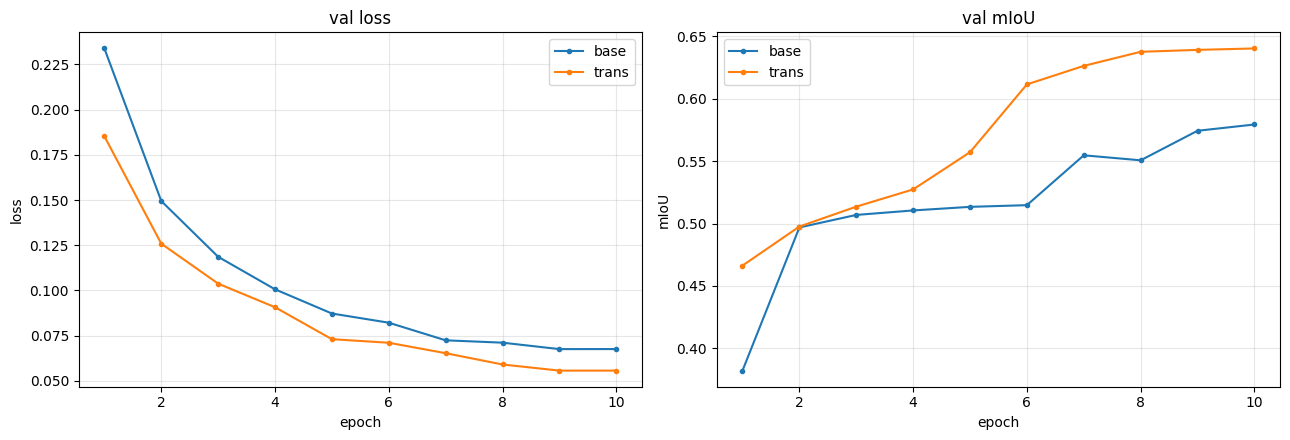

In [20]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for r in summary['results']:
    if r['status'] != 'ok':
        continue
    metrics_csv = Path(r['config_dir']) / 'metrics.csv'
    if not metrics_csv.exists():
        continue
    epochs, tloss, vloss, mious = [], [], [], []
    with metrics_csv.open() as f:
        for row in csv.DictReader(f):
            epochs.append(int(row['epoch']))
            tloss.append(float(row['train_loss']))
            vloss.append(float(row['val_loss']))
            mious.append(float(row['mIoU']))
    axes[0].plot(epochs, vloss, marker='o', markersize=3, label=r['tag'])
    axes[1].plot(epochs, mious, marker='o', markersize=3, label=r['tag'])

axes[0].set_title('val loss');  axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[1].set_title('val mIoU'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('mIoU')
for ax in axes:
    ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
plt.show()

## 8. Per-class IoU breakdown

MassMIND's interesting question is `living_obs` (0.05 % of pixels). The summary
table only shows mIoU; this cell pulls the per-class IoU at each config's best epoch.

In [21]:
import csv
from pathlib import Path

import pandas as pd

CLASS_NAMES = ['sky', 'water', 'bridge', 'obstacle', 'living_obs', 'background', 'self']

per_class_rows = []
for r in summary['results']:
    if r['status'] != 'ok':
        continue
    metrics_csv = Path(r['config_dir']) / 'metrics.csv'
    if not metrics_csv.exists():
        continue
    best_row = None
    best_miou = -1.0
    with metrics_csv.open() as f:
        for row in csv.DictReader(f):
            v = float(row['mIoU'])
            if v > best_miou:
                best_miou = v
                best_row = row
    if best_row is None:
        continue
    entry = {'config': r['tag'], 'epoch': int(best_row['epoch']), 'mIoU': best_miou}
    for name in CLASS_NAMES:
        entry[name] = float(best_row.get(f'iou_{name}', float('nan')))
    per_class_rows.append(entry)

per_class = pd.DataFrame(per_class_rows)
print(per_class.to_string(index=False))

config  epoch    mIoU     sky   water  bridge  obstacle  living_obs  background    self
  base     10 0.57941 0.98337 0.98168 0.32994   0.05876         0.0     0.81307 0.88903
 trans     10 0.64037 0.98403 0.98261 0.42429   0.35076         0.0     0.82554 0.91537


## 9. Package outputs for download

Zips the probe directory into `/kaggle/working/probe_<timestamp>.zip`. The zip
is automatically published to the **Output tab** of the saved version — click
"Download All" to grab everything (checkpoints + metrics + summary + plots).

In [22]:
import shutil
from pathlib import Path

src_dir = Path(PROBE_OUTPUT_DIR)
archive = shutil.make_archive(str(src_dir), 'zip', root_dir=src_dir.parent, base_dir=src_dir.name)
print('Wrote archive:', archive)
print('Size (MB):  ', round(Path(archive).stat().st_size / 1e6, 1))

Wrote archive: /kaggle/working/probe_1778849646.zip
Size (MB):   569.0
